# Model with conditional interaction

- Author: [givasile](https://givasile.github.io/)
- Runtime: ~5 s
- Description: Regional effects (PDP, ALE, RHALE) on a model with a
  conditional interaction: every method must find the split on $x_2$ at 0 and
  recover the per-region closed forms, tested against `effector.benchmarks`.

In this example, we show regional effects of a model with conditional interactions using PDP, ALE, and RHALE.
In particular, we:

1. show how to use `effector` to estimate the regional effects using PDP, ALE, and RHALE
2. provide the analytical formulas for the regional effects
3. test that (1) and (2) match

We will use the following model: 

$$ 
f(x_1, x_2, x_3) = -x_1^2 \mathbb{1}_{x_2 <0} + x_1^2 \mathbb{1}_{x_2 \geq 0} + e^{x_3} 
$$

where the features $x_1, x_2, x_3$ are independent and uniformly distributed in the interval $[-1, 1]$.


The model has an _interaction_ between $x_1$ and $x_2$ caused by the terms: 
$f_{1,2}(x_1, x_2) = -x_1^2 \mathbb{1}_{x_2 <0} + x_1^2 \mathbb{1}_{x_2 \geq 0}$.
This means that the effect of $x_1$ on the output $y$ depends on the value of $x_2$ and vice versa.
Therefore, there is no golden standard on how to split the effect of $f_{1,2}$ to two parts, one that corresponds to $x_1$ and one to $x_2$.
Each global effect method has a different strategy to handle this issue.
Below we will see how PDP, ALE, and RHALE handle this interaction.

In contrast, $x_3$ does not interact with any other feature, so its effect can be easily computed as $e^{x_3}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import effector

np.random.seed(21)

bench = effector.benchmarks.ConditionalInteractionUniform()
model = bench.model
dataset = bench.dataset
x = bench.generate_data(1_000)

## Why regional effects?

As shown in the [global-effects notebook](./05_conditional_interaction_independent_uniform_global.md),
the global effect of $x_1$ is **zero with high heterogeneity**: for instances
with $x_2 < 0$ the local effect is $-x_1^2$ and for $x_2 \geq 0$ it is $+x_1^2$,
so the average washes out.

Regional effect methods ask the natural follow-up: *is there a split of the
input space that makes the local effects agree within each subregion?* Here the
answer is known by construction — splitting on $x_2 = 0$ yields two regions
where the effect of $x_1$ is deterministic:

$$
\text{effect}(x_1 \mid x_2 < 0) = -x_1^2, \qquad
\text{effect}(x_1 \mid x_2 \geq 0) = +x_1^2,
$$

each with **zero** heterogeneity. After zero-integral centering over
$x_1 \in [-1, 1]$ (the mean of $x_1^2$ is $1/3$), the closed forms are
$\mp x_1^2 \pm 1/3$. Every regional method below must recover: the split
feature ($x_2$), the split position ($\approx 0$), and the per-region curves.

## Regional PDP

### Effector

In [2]:
r_pdp = effector.RegionalPDP(x, model.predict, axis_limits=dataset.axis_limits)
r_pdp.fit(0)
r_pdp.summary(0)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 81.43it/s]



Feature 0 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
x_0 🔹 [id: 0 | heter: 0.10 | inst: 1000 | w: 1.00]
    x_1 ≤ 0.00 🔹 [id: 1 | heter: 0.00 | inst: 488 | w: 0.49]
    x_1 > 0.00 🔹 [id: 2 | heter: 0.00 | inst: 512 | w: 0.51]
--------------------------------------------------
Feature 0 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 0.10
    Level 1🔹heter: 0.00 | 🔻0.10 (100.00%)




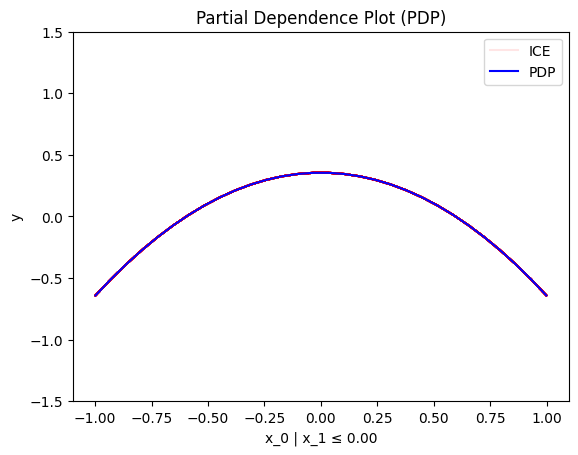

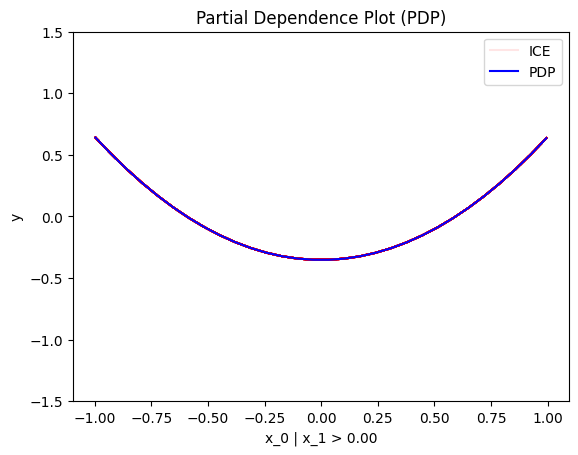

In [3]:
for node_idx in [1, 2]:
    r_pdp.plot(feature=0, node_idx=node_idx, heterogeneity="ice", centering=True, y_limits=[-1.5, 1.5])

### Tests

In [4]:
# the same closed forms the test suite asserts against
# (tests/test_functional_conditional_interaction.py::TestRegionalEffects)
xx = np.linspace(-1, 1, 100)


def check_regions(reg):
    tree = reg.tree["feature_0"]
    children = [n for n in tree.nodes if n.info["level"] == 1]
    assert len(children) == 2
    for node in children:
        # the split must be on x2 at ~0
        assert node.info["foc_index"] == bench.regional_split_feature
        assert abs(node.info["foc_split_position"] - bench.regional_split_position) <= 0.15
        # inside each region: -+x1^2 (centered), with ~zero heterogeneity
        side = "left" if node.info["comparison"] == "<=" else "right"
        y, heter = reg.eval(0, node.idx, xx, heterogeneity=True, centering=True)
        np.testing.assert_allclose(y, bench.regional_effect_gt(side, xx), atol=1e-1)
        np.testing.assert_allclose(heter, np.zeros_like(xx), atol=1e-1)


check_regions(r_pdp)

## Regional ALE

### Effector

In [5]:
r_ale = effector.RegionalALE(x, model.predict, axis_limits=dataset.axis_limits)
r_ale.fit(0)
r_ale.summary(0)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 56.13it/s]



Feature 0 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
x_0 🔹 [id: 0 | heter: 1.39 | inst: 1000 | w: 1.00]
    x_1 ≤ 0.00 🔹 [id: 1 | heter: 0.00 | inst: 488 | w: 0.49]
    x_1 > 0.00 🔹 [id: 2 | heter: 0.00 | inst: 512 | w: 0.51]
--------------------------------------------------
Feature 0 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 1.39
    Level 1🔹heter: 0.00 | 🔻1.39 (100.00%)




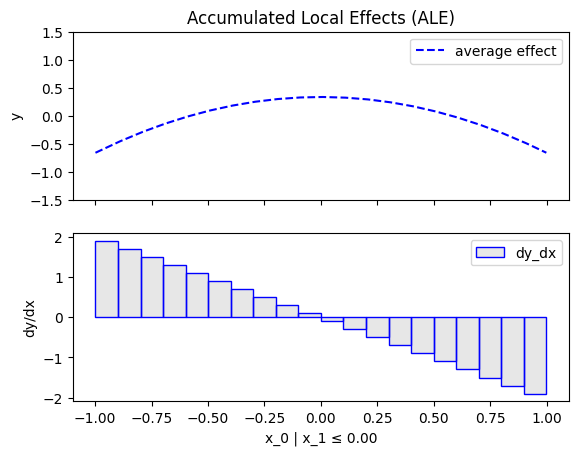

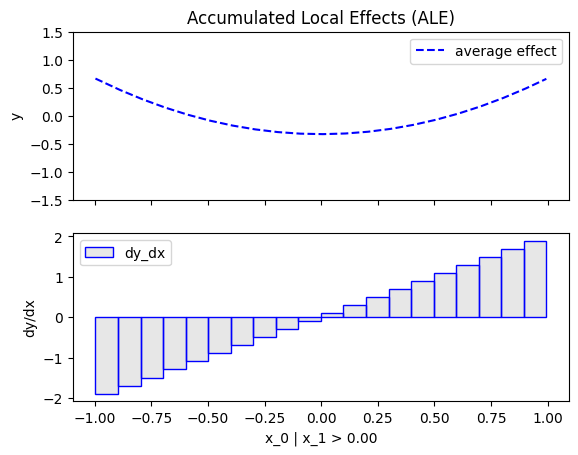

In [6]:
for node_idx in [1, 2]:
    r_ale.plot(feature=0, node_idx=node_idx, centering=True, y_limits=[-1.5, 1.5])

### Tests

In [7]:
check_regions(r_ale)

## Regional RHALE

### Effector

In [8]:
r_rhale = effector.RegionalRHALE(x, model.predict, model.jacobian, axis_limits=dataset.axis_limits)
r_rhale.fit(0)
r_rhale.summary(0)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.26it/s]

100%|██████████| 1/1 [00:00<00:00,  3.26it/s]



Feature 0 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
x_0 🔹 [id: 0 | heter: 1.39 | inst: 1000 | w: 1.00]
    x_1 ≤ 0.00 🔹 [id: 1 | heter: 0.00 | inst: 488 | w: 0.49]
    x_1 > 0.00 🔹 [id: 2 | heter: 0.00 | inst: 512 | w: 0.51]
--------------------------------------------------
Feature 0 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 1.39
    Level 1🔹heter: 0.00 | 🔻1.39 (99.77%)




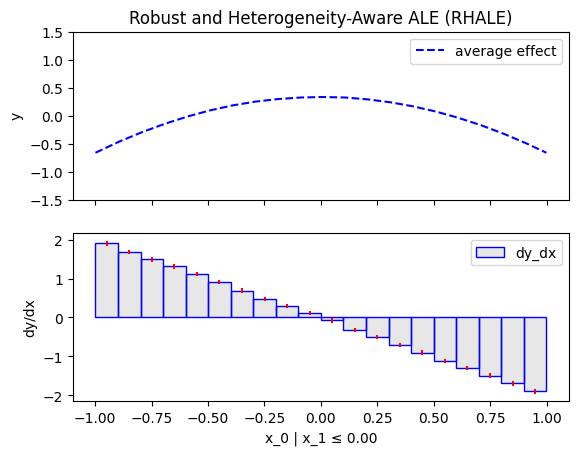

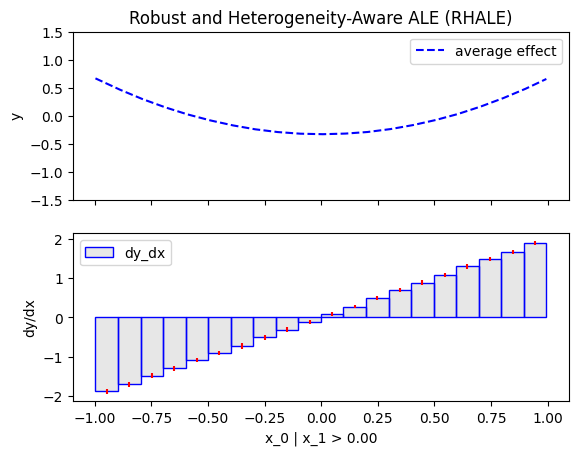

In [9]:
for node_idx in [1, 2]:
    r_rhale.plot(feature=0, node_idx=node_idx, centering=True, y_limits=[-1.5, 1.5])

### Tests

In [10]:
check_regions(r_rhale)

## Conclusions

All three regional methods recover the ground truth: they split on $x_2$ at
$\approx 0$ and, inside each region, report the deterministic effect
$\mp x_1^2$ (centered) with heterogeneity dropping from $\sim 0.1$ at the root
to $\approx 0$ — the model's conditional interaction is *fully explained* by a
single split. This is the ideal-case benchmark for regional methods: when a
crisp subspace structure exists, the methods must find exactly it.